In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si
import pandas as pd
import seaborn as sns

from utilsVanilla import *


In [2]:
S0 = 100
V0 = 0.04
r = 0.05
rho = -0.5
kappa = 1.5
theta = 0.04
sigma = 0.25 
xi = 0.25   
M = 15000
dt = 0.001
seed = 42

K_list = np.linspace(75, 125, 50)  # Strike prices
T_list = np.linspace(0.2, 2, 50)  # Maturity times


In [ ]:
 
pricefield = grid(S0, V0, r, kappa, theta, sigma, rho, K_list, T_list, M, dt, seed)

price_mc, price_analytic, iv_mc, iv_analytic = build_surfaces(pricefield ,S0, r, K_list, T_list)

# Plot call price surfaces
visualize_surface(K_list, T_list, price_mc, "MC Heston Call Price Surface", "Call Price")
visualize_surface(K_list, T_list, price_analytic, "Analytic Heston Call Price Surface", "Call Price")

# Plot implied volatility surfaces
visualize_surface(K_list, T_list, iv_mc, "MC Implied Volatility Surface", "Implied Volatility")
visualize_surface(K_list, T_list, iv_analytic, "Analytic Implied Volatility Surface", "Implied Volatility")

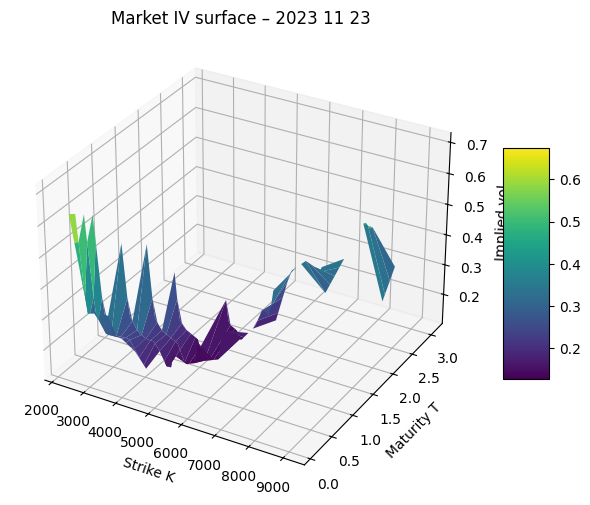

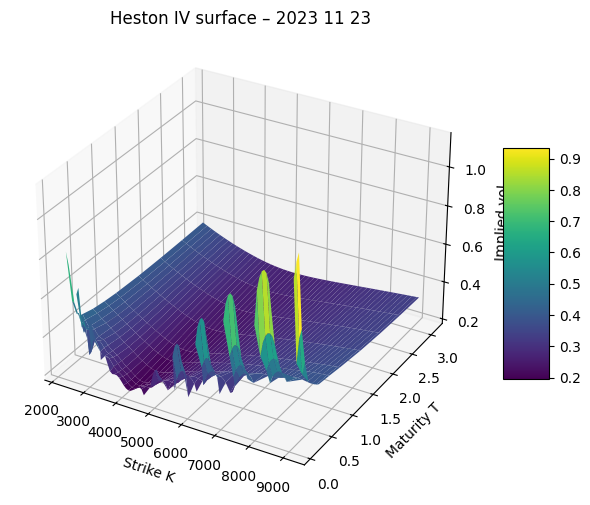

=== 2023 11 23 ===
theta_hat = [rho, V0, theta, kappa, sigma] :
[-0.26992365  0.050102    1.99999906  0.04799488  1.29414197]
RMSE = 7.9991e-02,   MAE = 6.1459e-02,   MaxErr = 2.3350e-01



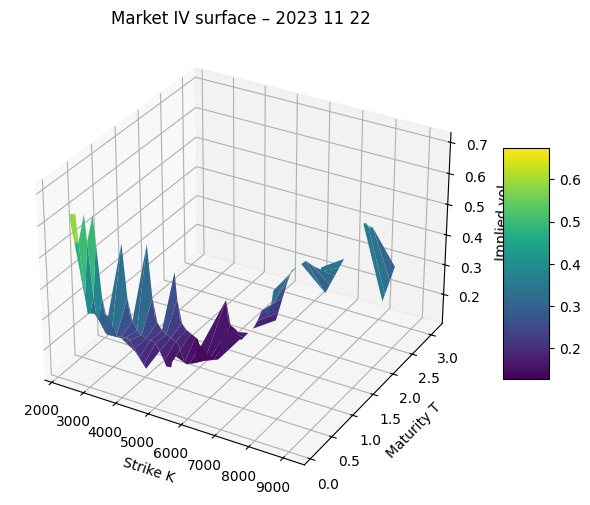

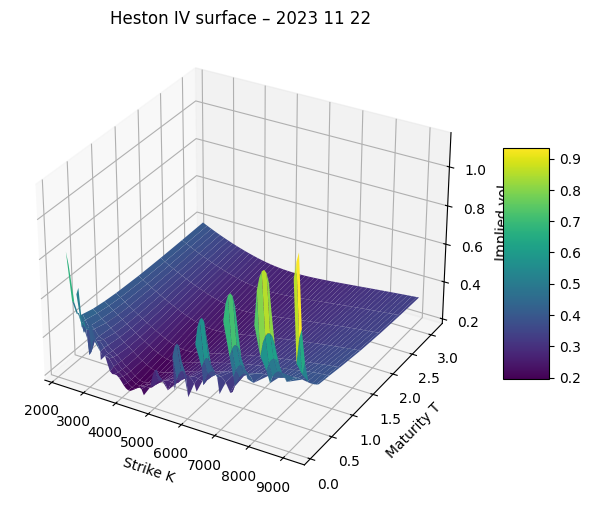

=== 2023 11 22 ===
theta_hat = [rho, V0, theta, kappa, sigma] :
[-0.26992365  0.050102    1.99999906  0.04799488  1.29414197]
RMSE = 7.9991e-02,   MAE = 6.1459e-02,   MaxErr = 2.3350e-01



In [3]:
# 1) load data
surfaces = load_ivol_surfaces('data/interp_ivol_surfaces.npy')

# 2) choose two trade dates present in the archive
dates = list(surfaces.keys())[:2]       # first two just for demo

S0 = 4000

results = {}
for d in dates:
    theta, err, _ = run_calibration_on_date(d, surfaces, S0, r)
    results[d] = {"theta": theta, "err": err}